Import Libraries and Clean the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map each scenario name to its CSV file
csv_files = {
    '01-Baseline': '01-Baseline.csv',
    'SentimentShock': '02-SentimentShock.csv',
    'HerdingSensitivity': '03-HerdingSensitivity.csv',
    'VisionRadiusSweep': '04-VisionRadiusSweep.csv',
    'RandomSentimentComparison': '05-RandomSentimentComparison.csv',
    'Dataset': '06-Dataset.csv',
}

dataframes = {}
for scenario_name, file_path in csv_files.items():
    # Read each CSV, skipping the 6 NetLogo metadata rows
    df = pd.read_csv(file_path, skiprows=6)

    # Clean up column names (remove quotes and brackets)
    df.columns = [str(c).strip().replace('"', '').replace('[run number]', 'run').replace('[step]', 'tick') for c in df.columns]

    # Add scenario identifier
    df['Scenario'] = scenario_name
    dataframes[scenario_name] = df

# Combine all CSVs into one master DataFrame
df_all = pd.concat(dataframes.values(), ignore_index=True)
print("Data loaded successfully! Scenarios found:", list(dataframes.keys()))

Data loaded successfully! Scenarios found: ['01-Baseline', 'SentimentShock', 'HerdingSensitivity', 'VisionRadiusSweep', 'RandomSentimentComparison', 'Dataset']


Generate the Time-Series Plots (Price & Herding)

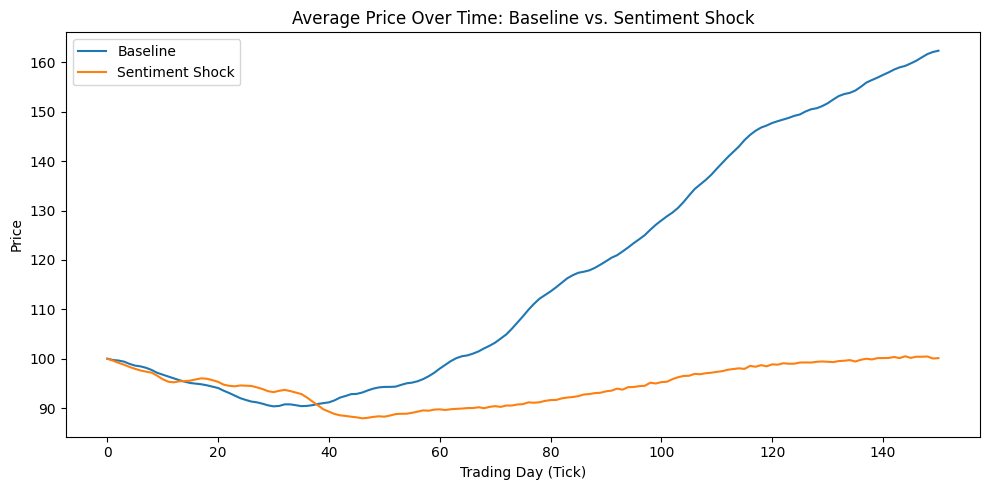

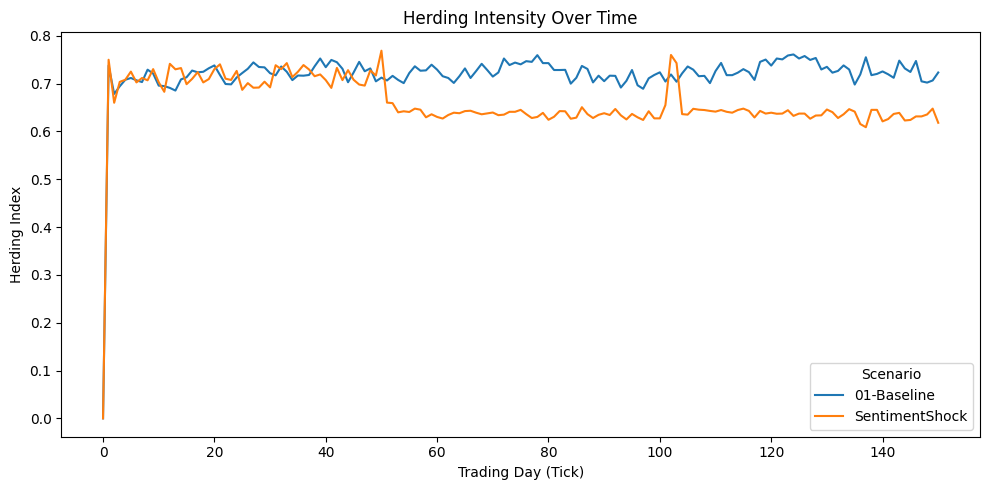

In [2]:
plt.style.use('default')

# 1. Price vs. Time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_all[df_all['Scenario'] == '01-Baseline'], x='tick', y='price', label='Baseline', errorbar=None)
sns.lineplot(data=df_all[df_all['Scenario'] == 'SentimentShock'], x='tick', y='price', label='Sentiment Shock', errorbar=None)
plt.title('Average Price Over Time: Baseline vs. Sentiment Shock')
plt.xlabel('Trading Day (Tick)')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Herding Intensity Over Time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_all[df_all['Scenario'].isin(['01-Baseline', 'SentimentShock'])],
             x='tick', y='herding-index', hue='Scenario', errorbar=None)
plt.title('Herding Intensity Over Time')
plt.xlabel('Trading Day (Tick)')
plt.ylabel('Herding Index')
plt.tight_layout()
plt.show()

Generate the Volatility Boxplots

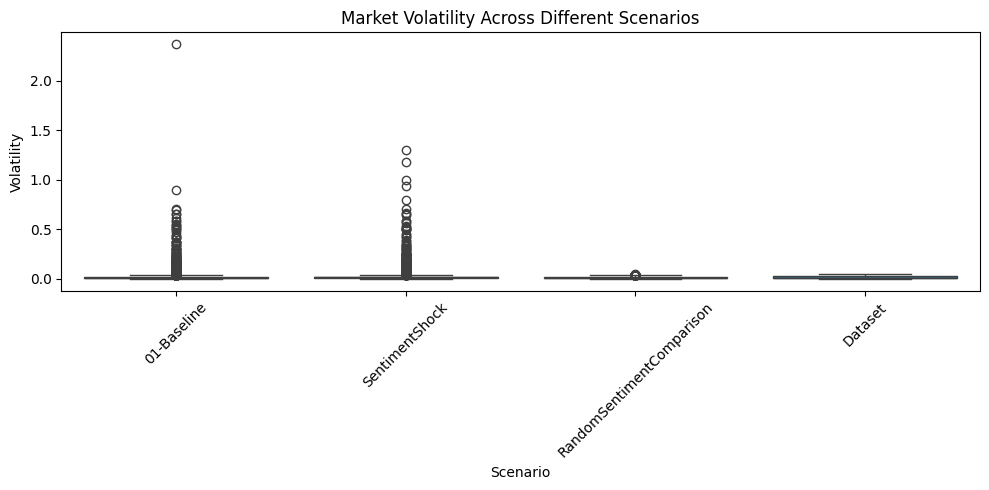

In [3]:
# 3. Market Volatility Boxplots
plt.figure(figsize=(10, 5))
scenarios_to_plot = ['01-Baseline', 'SentimentShock', 'RandomSentimentComparison', 'Dataset']
sns.boxplot(data=df_all[df_all['Scenario'].isin(scenarios_to_plot)], x='Scenario', y='volatility')
plt.title('Market Volatility Across Different Scenarios')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Generate the Correlation Heatmap

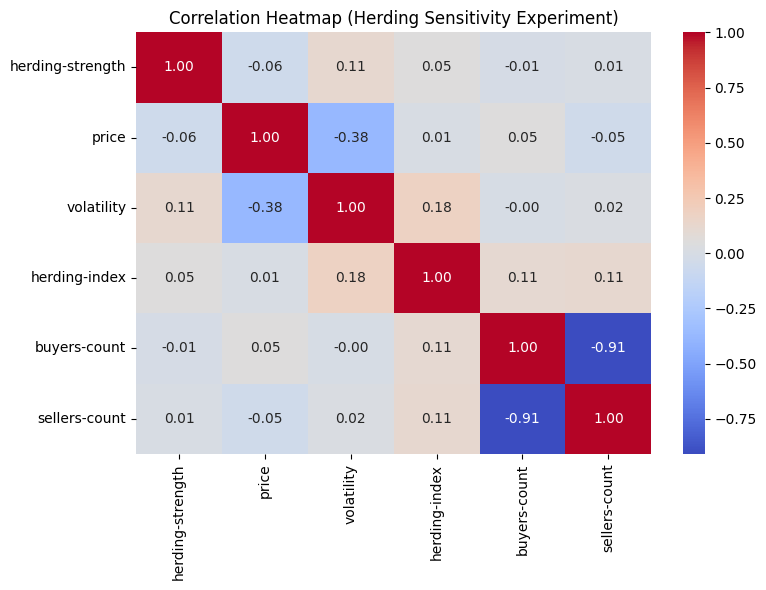

In [4]:
# 4. Correlation Heatmap (Herding Sensitivity Experiment)
df_sens = dataframes['HerdingSensitivity']

plt.figure(figsize=(8, 6))
# Select the numeric columns we want to correlate
cols_to_correlate = ['herding-strength', 'price', 'volatility', 'herding-index', 'buyers-count', 'sellers-count']
corr_matrix = df_sens[cols_to_correlate].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Herding Sensitivity Experiment)')
plt.tight_layout()
plt.show()

In [5]:
# 5. Descriptive Statistics Table
# Group the data by Scenario and calculate the mean and standard deviation
stats_summary = df_all.groupby('Scenario').agg(
    Mean_Price=('price', 'mean'),
    Price_Std_Dev=('price', 'std'),
    Mean_Volatility=('volatility', 'mean'),
    Mean_Herding_Index=('herding-index', 'mean')
).reset_index()

# Round the numbers to make the table clean and readable (similar to the LaTeX table)
stats_summary = stats_summary.round(3)

# Print the final table
print("--- Descriptive Statistics Across Simulation Scenarios ---")
print(stats_summary.to_string(index=False))

--- Descriptive Statistics Across Simulation Scenarios ---
                 Scenario  Mean_Price  Price_Std_Dev  Mean_Volatility  Mean_Herding_Index
              01-Baseline     117.142        105.988            0.021               0.719
                  Dataset      99.978          2.330            0.016               0.660
       HerdingSensitivity     102.257         39.325            0.021               0.657
RandomSentimentComparison     100.166          2.092            0.012               0.635
           SentimentShock      94.625         41.229            0.026               0.660
        VisionRadiusSweep      97.587         41.739            0.025               0.663


In [6]:
import scipy.stats as stats

# 1. Average each run down to one value first (fixes pseudo-replication)
df_sens = df_all[df_all['Scenario'] == 'HerdingSensitivity']

run_means = df_sens.groupby(['run', 'herding-strength']).agg(
    mean_volatility=('volatility', 'mean')
).reset_index()

# 2. Calculate the correlation on the per-run averages
corr, pval = stats.pearsonr(run_means['herding-strength'], run_means['mean_volatility'])

print(f"Correlation (per-run averaged): {corr:.4f}, p-value: {pval:.4e}")

Correlation (per-run averaged): 0.3446, p-value: 4.2710e-08


In [7]:
import scipy.stats as stats

# Fat tails: excess kurtosis of returns per scenario (0 = normal bell curve, >0 = fat tails)
kurtosis_by_scenario = df_all[df_all['tick'] > 0].groupby('Scenario')['current-return'].apply(
    lambda x: stats.kurtosis(x.dropna(), fisher=True)
).reset_index(name='excess_kurtosis')

print("--- Fat Tails Check (Excess Kurtosis of Returns) ---")
print(kurtosis_by_scenario.to_string(index=False))

--- Fat Tails Check (Excess Kurtosis of Returns) ---
                 Scenario  excess_kurtosis
              01-Baseline       451.826981
                  Dataset        -0.633593
       HerdingSensitivity       300.776412
RandomSentimentComparison        -0.402595
           SentimentShock       122.690961
        VisionRadiusSweep       301.920675


In [8]:
# Fat tails, filtered to exclude price-floor rebound artifacts (price ≤ 15)
filtered = df_all[(df_all['tick'] > 0) & (df_all['price'] > 15)]

kurtosis_filtered = filtered.groupby('Scenario')['current-return'].apply(
    lambda x: stats.kurtosis(x.dropna(), fisher=True)
).reset_index(name='excess_kurtosis_filtered')

print("--- Fat Tails Check (Excluding Price-Floor Artifacts, price > 5) ---")
print(kurtosis_filtered.to_string(index=False))

--- Fat Tails Check (Excluding Price-Floor Artifacts, price > 5) ---
                 Scenario  excess_kurtosis_filtered
              01-Baseline                 24.531430
                  Dataset                 -0.633593
       HerdingSensitivity                  4.753932
RandomSentimentComparison                 -0.402595
           SentimentShock                  2.953117
        VisionRadiusSweep                  4.281431


In [9]:
# Check for extreme outlier returns driving the inflated kurtosis
outlier_check = df_all[df_all['tick'] > 0].groupby('Scenario')['current-return'].agg(
    ['min', 'max', 'mean', 'std']
).round(4)

print("--- Outlier Check on Returns ---")
print(outlier_check.to_string())

--- Outlier Check on Returns ---
                              min     max    mean     std
Scenario                                                 
01-Baseline               -0.6970  2.3684 -0.0043  0.0641
Dataset                   -0.0420  0.0449  0.0002  0.0196
HerdingSensitivity        -0.6970  2.0000  0.0015  0.0558
RandomSentimentComparison -0.0428  0.0443  0.0001  0.0151
SentimentShock            -0.6667  1.3000  0.0020  0.0631
VisionRadiusSweep         -0.7222  2.8000  0.0019  0.0641


In [10]:
import numpy as np

def autocorr_per_run(df, col, lag):
    """Average autocorrelation of col at a given lag, acr
    oss all runs."""
    values = []
    for run_id, run_df in df.groupby('run'):
        run_df = run_df.sort_values('tick')
        s = run_df[(run_df['tick'] > 0) & (run_df['price'] > 15)][col].dropna().reset_index(drop=True)
        if len(s) > lag:
            val = s.autocorr(lag=lag)
            if not np.isnan(val):
                values.append(val)
    return sum(values) / len(values) if values else float('nan')

print("--- Volatility Clustering Check (Autocorrelation of Volatility) ---")
for scenario in df_all['Scenario'].unique():
    df_scenario = df_all[df_all['Scenario'] == scenario]
    ac1 = autocorr_per_run(df_scenario, 'volatility', 1)
    ac5 = autocorr_per_run(df_scenario, 'volatility', 5)
    print(f"{scenario}: lag1={ac1:.3f}, lag5={ac5:.3f}")

--- Volatility Clustering Check (Autocorrelation of Volatility) ---
01-Baseline: lag1=0.826, lag5=0.624
SentimentShock: lag1=0.650, lag5=0.451
HerdingSensitivity: lag1=0.577, lag5=0.438
VisionRadiusSweep: lag1=0.616, lag5=0.427
RandomSentimentComparison: lag1=-0.192, lag5=0.010
Dataset: lag1=-0.282, lag5=-0.090


In [11]:
baseline_extreme = df_all[(df_all['Scenario'] == '01-Baseline') & (df_all['tick'] > 0) & (df_all['current-return'].abs() > 0.5)]
print(f"Number of extreme-return ticks in Baseline: {len(baseline_extreme)}")
print(baseline_extreme[['run', 'tick', 'price', 'current-return']].sort_values('current-return', ascending=False).head(15).to_string(index=False))

Number of extreme-return ticks in Baseline: 14
 run  tick  price  current-return
   5   110    6.4        2.368421
   5   109    1.9        0.900000
   5   111   10.9        0.703125
   9    53   12.2        0.584416
   8    43    2.2       -0.511111
  24    42    1.0       -0.523810
  24    41    2.1       -0.533333
   8    44    1.0       -0.545455
   7    61    1.3       -0.551724
  26    51    1.4       -0.588235
   2    40    1.0       -0.615385
  28    46    1.0       -0.655172
  20    48    1.0       -0.655172
  30    41    1.0       -0.696970


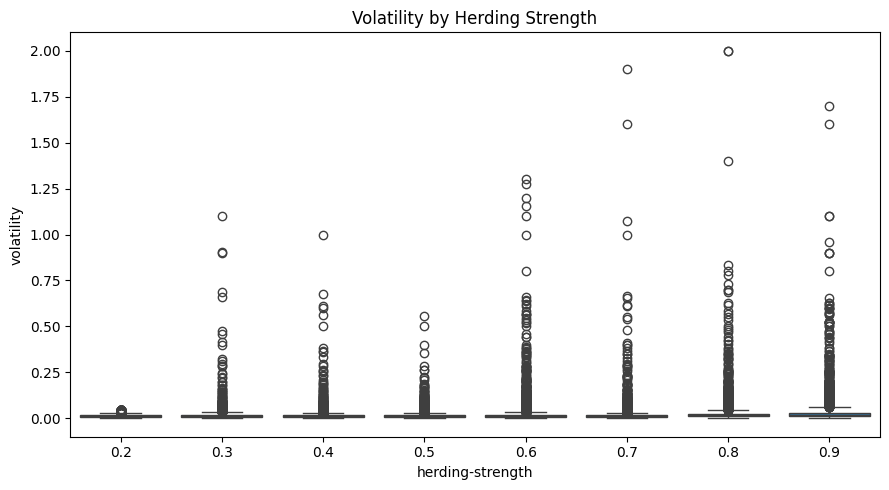

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_all[df_all['Scenario'] == 'HerdingSensitivity'],
            x='herding-strength', y='volatility')
plt.title('Volatility by Herding Strength')
plt.tight_layout()
plt.show()

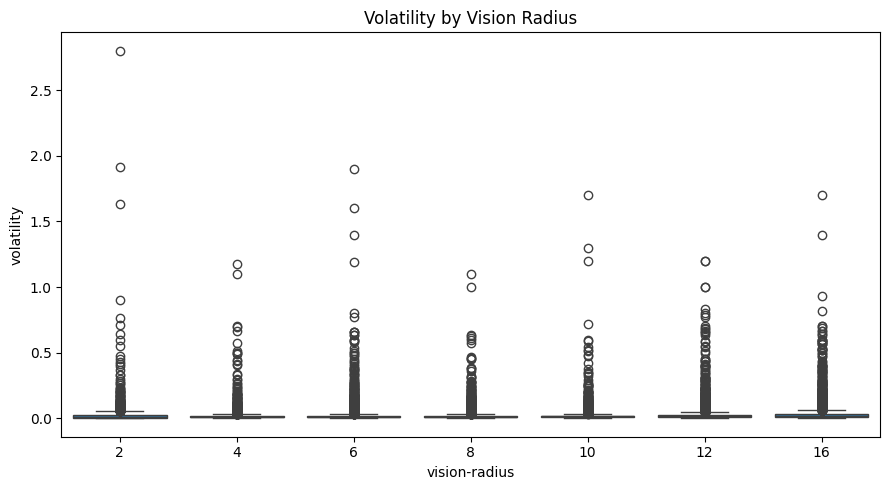

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_all[df_all['Scenario'] == 'VisionRadiusSweep'],
            x='vision-radius', y='volatility')
plt.title('Volatility by Vision Radius')
plt.tight_layout()
plt.show()

In [14]:
import scipy.stats as stats
import numpy as np

# --- 1. Per-run means (the correct unit of analysis) ---
run_level = df_all[df_all['tick'] > 0].groupby(['Scenario', 'run']).agg(
    mean_price=('price', 'mean'),
    mean_volatility=('volatility', 'mean'),
    mean_herding=('herding-index', 'mean')
).reset_index()

# --- 2. Table 3 rebuilt with 95% CIs (t-distribution, since n=30 per scenario) ---
def ci95(x):
    x = x.dropna()
    n = len(x)
    m, se = x.mean(), stats.sem(x)
    h = se * stats.t.ppf(0.975, n - 1)
    return pd.Series({'mean': m, 'std': x.std(), 'n': n, 'ci_low': m - h, 'ci_high': m + h})

for metric in ['mean_price', 'mean_volatility', 'mean_herding']:
    print(f"\n--- 95% CI for {metric} by scenario ---")
    print(run_level.groupby('Scenario')[metric].apply(ci95).unstack().round(3))

# --- 3. Baseline vs. SentimentShock: Welch's t-test (unequal variances) ---
base = run_level[run_level['Scenario'] == '01-Baseline']
shock = run_level[run_level['Scenario'] == 'SentimentShock']

for metric in ['mean_price', 'mean_volatility']:
    t, p = stats.ttest_ind(base[metric], shock[metric], equal_var=False)
    print(f"Baseline vs SentimentShock, {metric}: t = {t:.3f}, p = {p:.4g}")

# --- 4. Four-scenario volatility comparison: one-way ANOVA ---
groups = [run_level[run_level['Scenario'] == s]['mean_volatility'].dropna()
          for s in ['01-Baseline', 'SentimentShock', 'RandomSentimentComparison', 'Dataset']]
f, p = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA, volatility across 4 scenarios: F = {f:.3f}, p = {p:.4g}")


--- 95% CI for mean_price by scenario ---
                              mean     std      n  ci_low  ci_high
Scenario                                                          
01-Baseline                117.256  93.675   30.0  82.277  152.235
Dataset                     99.977   0.666   30.0  99.729  100.226
HerdingSensitivity         102.272  32.060  240.0  98.195  106.349
RandomSentimentComparison  100.167   1.079   30.0  99.765  100.570
SentimentShock              94.589  34.036   30.0  81.880  107.299
VisionRadiusSweep           97.571  33.955  210.0  92.951  102.190

--- 95% CI for mean_volatility by scenario ---
                            mean    std      n  ci_low  ci_high
Scenario                                                       
01-Baseline                0.022  0.013   30.0   0.017    0.026
Dataset                    0.016  0.002   30.0   0.015    0.017
HerdingSensitivity         0.022  0.017  240.0   0.019    0.024
RandomSentimentComparison  0.013  0.002   30.0   0.01

In [15]:
print(run_level[run_level['Scenario'] == 'Dataset']['mean_volatility'].std())

0.0015314336910268217
